Task 1 - latency vs batch size

In [2]:
import time
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForMaskedLM

In [3]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

model.eval()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

DistilBertForMaskedLM(
  (activation): GELUActivation()
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0

In [4]:
texts = [
    "Inference engineering improves model performance.",
    "Model latency is important for fast responses.",
    "Batching can improve inference efficiency.",
    "Quantization can reduce model memory usage.",
    "CPU inference is useful for lightweight models.",
    "Efficient serving can increase throughput.",
    "KV cache helps speed up text generation.",
    "Model optimization reduces inference cost."
]

In [5]:
inputs = tokenizer(texts,return_tensors="pt",padding=True,truncation=True)

In [6]:
batch_sizes = [1, 2, 4, 8]

total_times = []
time_per_sample = []

for batch_size in batch_sizes:

    batch = {
        key: value[:batch_size]
        for key, value in inputs.items()
    }

    with torch.no_grad():
        model(**batch)

    start_time = time.perf_counter()

    with torch.no_grad():
        model(**batch)

    end_time = time.perf_counter()

    total_time = end_time - start_time
    per_sample = total_time / batch_size

    total_times.append(total_time)
    time_per_sample.append(per_sample)

    print(f"Batch Size: {batch_size}")
    print(f"Total Time: {total_time:.4f} seconds")
    print(f"Time per Sample: {per_sample:.4f} seconds")
    print("-" * 35)

Batch Size: 1
Total Time: 0.3538 seconds
Time per Sample: 0.3538 seconds
-----------------------------------
Batch Size: 2
Total Time: 0.3951 seconds
Time per Sample: 0.1976 seconds
-----------------------------------
Batch Size: 4
Total Time: 0.4904 seconds
Time per Sample: 0.1226 seconds
-----------------------------------
Batch Size: 8
Total Time: 1.1903 seconds
Time per Sample: 0.1488 seconds
-----------------------------------


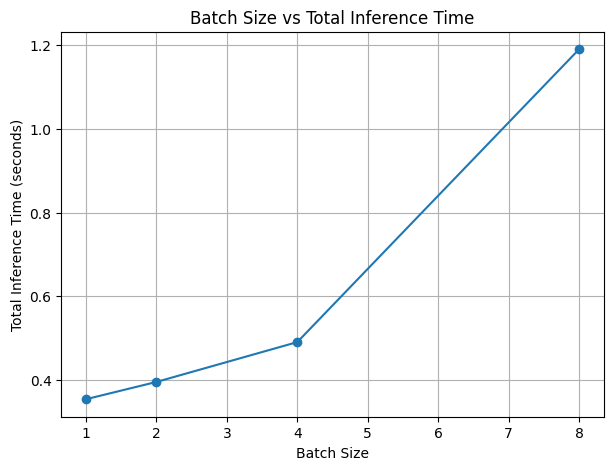

In [7]:
plt.figure(figsize=(7, 5))

plt.plot(batch_sizes, total_times, marker="o")

plt.xlabel("Batch Size")
plt.ylabel("Total Inference Time (seconds)")
plt.title("Batch Size vs Total Inference Time")

plt.grid(True)
plt.show()

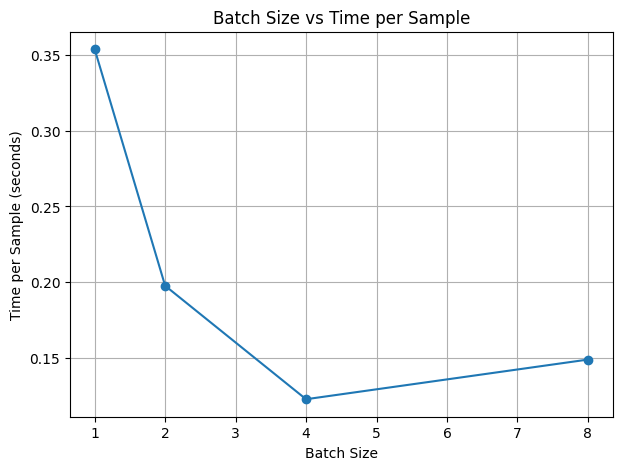

In [8]:
plt.figure(figsize=(7, 5))

plt.plot(batch_sizes, time_per_sample, marker="o")

plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (seconds)")
plt.title("Batch Size vs Time per Sample")

plt.grid(True)
plt.show()


As the batch size increases, the total inference time generally increases because more inputs are processed together. However, the time per sample may decrease because batching allows the CPU to process multiple inputs more efficiently.

Task 2 - Quantize the model

In [14]:
import os
quantized_model = torch.quantization.quantize_dynamic(model,{torch.nn.Linear}, dtype=torch.qint8)

print("Quantized model created.")

/tmp/ipykernel_1421/3083209806.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(model,{torch.nn.Linear}, dtype=torch.qint8)


Quantized model created.


In [15]:
quantized_model.eval()

DistilBertForMaskedLM(
  (activation): GELUActivation()
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (k_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (v_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (out_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme

In [16]:
torch.save(model.state_dict(), "original_model.pth")
torch.save(quantized_model.state_dict(), "quantized_model.pth")

original_size = os.path.getsize("original_model.pth") / (1024 * 1024)
quantized_size = os.path.getsize("quantized_model.pth") / (1024 * 1024)

print(f"Original Model Size: {original_size:.2f} MB")
print(f"Quantized Model Size: {quantized_size:.2f} MB")
print(f"Size Reduction: {original_size - quantized_size:.2f} MB")

Original Model Size: 255.57 MB
Quantized Model Size: 154.77 MB
Size Reduction: 100.80 MB


In [17]:
sample_texts = [
    "Inference engineering improves model performance.",
    "Quantization reduces model memory usage.",
    "CPU inference can be optimized.",
    "Efficient models can reduce inference cost."
]

sample_inputs = tokenizer(sample_texts, return_tensors="pt",padding=True,truncation=True
)

In [18]:
with torch.no_grad():
    model(**sample_inputs)

start_time = time.perf_counter()

with torch.no_grad():
    model(**sample_inputs)

end_time = time.perf_counter()

original_time = end_time - start_time

print(f"Original Model Inference Time: {original_time:.4f} seconds")

Original Model Inference Time: 0.4029 seconds


In [19]:
with torch.no_grad():
    quantized_model(**sample_inputs)

start_time = time.perf_counter()

with torch.no_grad():
    quantized_model(**sample_inputs)

end_time = time.perf_counter()

quantized_time = end_time - start_time

print(f"Quantized Model Inference Time: {quantized_time:.4f} seconds")

Quantized Model Inference Time: 0.1216 seconds


In [20]:
print("Inference Time Comparison")
print("-" * 35)

print(f"Original Model  : {original_time:.4f} seconds")
print(f"Quantized Model : {quantized_time:.4f} seconds")

if quantized_time < original_time:
    print("Quantized model is faster.")
else:
    print("Original model is faster in this run.")

Inference Time Comparison
-----------------------------------
Original Model  : 0.4029 seconds
Quantized Model : 0.1216 seconds
Quantized model is faster.



Quantization reduces the model size because the weights are stored using lower precision.
The quantized model may also provide faster CPU inference.